# Topic Modeling — Skenario S1 (Dataset Baru)

### Referensi
- IEEE Xplore (2025): *Topic Modelling Analysis on Indonesian News Using BERT Topic Model* 
- ScienceDirect (2022): *Topic Modeling Algorithms and Applications: A Survey* 
- IEEE Access (2022): *Topic Modeling: Perspectives From a Literature Review* 


In [16]:
!pip install gensim pyldavis bertopic sentence-transformers umap-learn hdbscan wordcloud -q


In [17]:
import json, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
warnings.filterwarnings('ignore')

# Gensim — LDA
import gensim.corpora as corpora
from gensim.models import LdaModel, CoherenceModel

# Sklearn — NMF
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.metrics.pairwise import cosine_similarity

# BERTopic stack
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN

# Visualisasi
import pyLDAvis
import pyLDAvis.gensim_models
from wordcloud import WordCloud


In [58]:
import os
import json
DATA_DIR   = '/Users/lathifash/Documents/PERKULIAHAN_SEM8/TEXT MINING/FP/fp-textmining'     # <-- UBAH sesuai lokasi file corpus_*.json
OUTPUT_DIR = '/Users/lathifash/Documents/PERKULIAHAN_SEM8/TEXT MINING/FP/fp-textmining/output'
os.makedirs(OUTPUT_DIR, exist_ok=True)

K_VALUES    = [5, 10, 15, 20, 25, 30]   
RANDOM_SEED = 42
PALETTE     = 'tab20'

print(f'DATA_DIR   : {os.path.abspath(DATA_DIR)}')
print(f'OUTPUT_DIR : {os.path.abspath(OUTPUT_DIR)}')
print(f'K values   : {K_VALUES}')


DATA_DIR   : /Users/lathifash/Documents/PERKULIAHAN_SEM8/TEXT MINING/FP/fp-textmining
OUTPUT_DIR : /Users/lathifash/Documents/PERKULIAHAN_SEM8/TEXT MINING/FP/fp-textmining/output
K values   : [5, 10, 15, 20, 25, 30]


In [65]:
with open(os.path.join(DATA_DIR, 'corpus_tokenized.json'), 'r', encoding='utf-8') as f:
    corpus_tokenized = json.load(f)   # list of list of str (sudah di-stem)

with open(os.path.join(DATA_DIR, 'corpus_bert.json'), 'r', encoding='utf-8') as f:
    corpus_bert = json.load(f)        # list of str (teks_nostop, belum di-stem)

with open(os.path.join(DATA_DIR, 'corpus_metadata.json'), 'r', encoding='utf-8') as f:
    metadata = json.load(f)

df_meta = pd.DataFrame(metadata)

print(f'Total dokumen    : {len(corpus_tokenized):,}')
print(f'Kolom metadata   : {df_meta.columns.tolist()}')
print(f'\nDistribusi portal:')
print(df_meta['portal'].value_counts().to_string())
print(f'\nDistribusi kategori:')
print(df_meta['kategori'].value_counts().to_string())


Total dokumen    : 20,334
Kolom metadata   : ['portal', 'kategori', 'judul']

Distribusi portal:
portal
detik           8677
antara          8550
tribun          2007
kompas           541
liputan6         330
cnnindonesia     229

Distribusi kategori:
kategori
ekonomi      4071
politik      3886
olahraga     3851
hiburan      3126
otomotif     1858
teknologi    1846
sains        1411
lifestyle     285


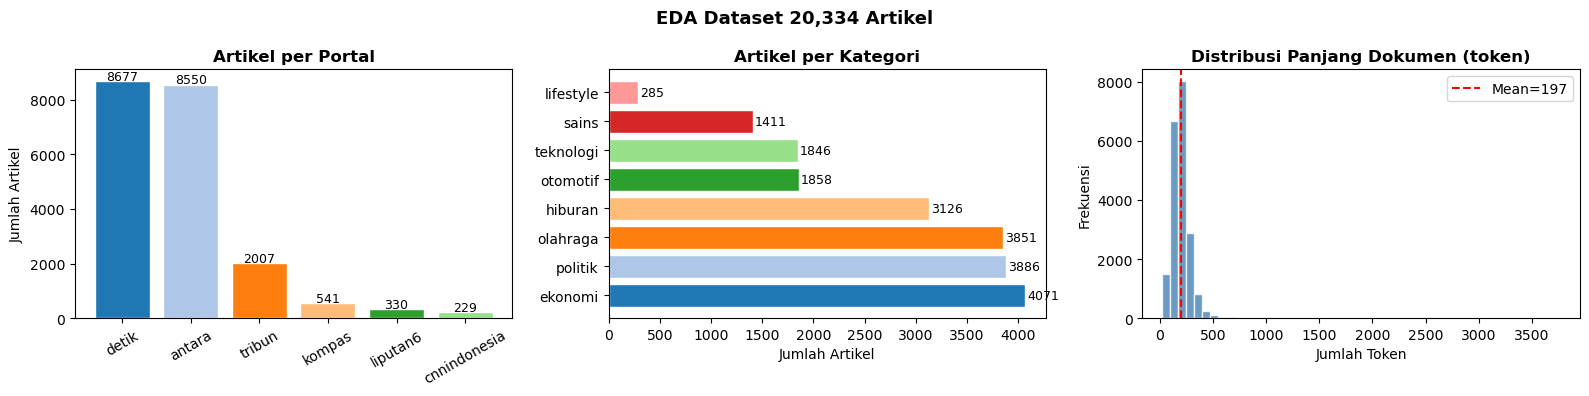

Rata-rata panjang dokumen : 197 token
Min/Max                 : 22/3766


In [60]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
portal_counts = df_meta['portal'].value_counts()
axes[0].bar(portal_counts.index, portal_counts.values,
            color=sns.color_palette(PALETTE, len(portal_counts)), edgecolor='white')
axes[0].set_title('Artikel per Portal', fontweight='bold')
axes[0].set_ylabel('Jumlah Artikel')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(portal_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=9)


kat_counts = df_meta['kategori'].value_counts()
axes[1].barh(kat_counts.index, kat_counts.values,
             color=sns.color_palette(PALETTE, len(kat_counts)), edgecolor='white')
axes[1].set_title('Artikel per Kategori', fontweight='bold')
axes[1].set_xlabel('Jumlah Artikel')
for i, v in enumerate(kat_counts.values):
    axes[1].text(v + 20, i, str(v), va='center', fontsize=9)

doc_lengths = [len(doc) for doc in corpus_tokenized]
axes[2].hist(doc_lengths, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[2].axvline(np.mean(doc_lengths), color='red', ls='--', label=f'Mean={np.mean(doc_lengths):.0f}')
axes[2].set_title('Distribusi Panjang Dokumen (token)', fontweight='bold')
axes[2].set_xlabel('Jumlah Token')
axes[2].set_ylabel('Frekuensi')
axes[2].legend()

plt.suptitle(f'EDA Dataset {len(corpus_tokenized):,} Artikel', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig00_eda_dataset.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'Rata-rata panjang dokumen : {np.mean(doc_lengths):.0f} token')
print(f'Min/Max                 : {min(doc_lengths)}/{max(doc_lengths)}')


## 1. LDA — Latent Dirichlet Allocation

In [61]:
id2word = corpora.Dictionary(corpus_tokenized)
print(f'Vocabulary sebelum filter : {len(id2word):,}')

# no_below=3 karena dataset lebih besar (≥10k dok)
# no_above=0.5 buang kata yang muncul di >50% dokumen
id2word.filter_extremes(no_below=3, no_above=0.5)
print(f'Vocabulary setelah filter  : {len(id2word):,}')

corpus_bow = [id2word.doc2bow(doc) for doc in corpus_tokenized]
print(f'Corpus BOW                 : {len(corpus_bow):,} dokumen')


Vocabulary sebelum filter : 64,373
Vocabulary setelah filter  : 27,668
Corpus BOW                 : 20,334 dokumen


In [62]:
lda_models     = {}
lda_coherence  = {}
lda_perplexity = {}

for k in K_VALUES:
    print(f'>>> Training LDA k={k} ...', end=' ', flush=True)
    lda = LdaModel(
        corpus          = corpus_bow,
        id2word         = id2word,
        num_topics      = k,
        random_state    = RANDOM_SEED,
        passes          = 10,
        iterations      = 100,
        alpha           = 'auto',
        eta             = 'auto',
        per_word_topics = True,
        eval_every      = None
    )
    lda_models[k] = lda

    # Coherence C_v
    cm = CoherenceModel(model=lda, texts=corpus_tokenized,
                        dictionary=id2word, coherence='c_v')
    lda_coherence[k]  = cm.get_coherence()
    lda_perplexity[k] = lda.log_perplexity(corpus_bow)
    print(f'C_v={lda_coherence[k]:.4f} | perp={lda_perplexity[k]:.2f}')

best_k_lda = max(lda_coherence, key=lda_coherence.get)
print(f'\n Best k LDA = {best_k_lda} (C_v = {lda_coherence[best_k_lda]:.4f})')


>>> Training LDA k=5 ... C_v=0.5201 | perp=-7.79
>>> Training LDA k=10 ... C_v=0.5787 | perp=-7.93
>>> Training LDA k=15 ... C_v=0.5862 | perp=-8.45
>>> Training LDA k=20 ... C_v=0.6076 | perp=-8.81
>>> Training LDA k=25 ... C_v=0.6162 | perp=-9.06
>>> Training LDA k=30 ... C_v=0.5854 | perp=-9.34

 Best k LDA = 25 (C_v = 0.6162)


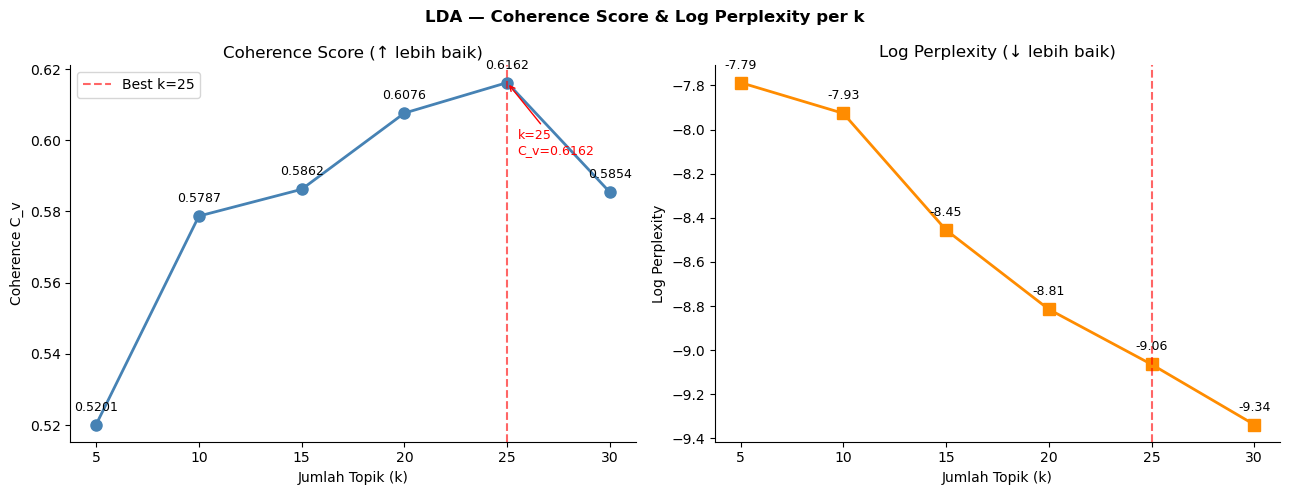

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('LDA — Coherence Score & Log Perplexity per k', fontweight='bold')

ks  = list(lda_coherence.keys())
cvs = list(lda_coherence.values())
pvs = list(lda_perplexity.values())

axes[0].plot(ks, cvs, marker='o', color='steelblue', lw=2, ms=8)
axes[0].axvline(best_k_lda, color='red', ls='--', alpha=0.6, label=f'Best k={best_k_lda}')
axes[0].annotate(f'k={best_k_lda}\nC_v={lda_coherence[best_k_lda]:.4f}',
                 xy=(best_k_lda, lda_coherence[best_k_lda]),
                 xytext=(best_k_lda+0.5, lda_coherence[best_k_lda]-0.02),
                 fontsize=9, color='red',
                 arrowprops=dict(arrowstyle='->', color='red', lw=1))
for k_v, cv_v in zip(ks, cvs):
    axes[0].annotate(f'{cv_v:.4f}', (k_v, cv_v), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9)
axes[0].set_xlabel('Jumlah Topik (k)'); axes[0].set_ylabel('Coherence C_v')
axes[0].set_title('Coherence Score (↑ lebih baik)'); axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

axes[1].plot(ks, pvs, marker='s', color='darkorange', lw=2, ms=8)
axes[1].axvline(best_k_lda, color='red', ls='--', alpha=0.6)
for k_v, pv in zip(ks, pvs):
    axes[1].annotate(f'{pv:.2f}', (k_v, pv), textcoords='offset points',
                     xytext=(0, 10), ha='center', fontsize=9)
axes[1].set_xlabel('Jumlah Topik (k)'); axes[1].set_ylabel('Log Perplexity')
axes[1].set_title('Log Perplexity (↓ lebih baik)')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig01_lda_coherence.png'), dpi=150, bbox_inches='tight')
plt.show()


In [67]:
best_lda        = lda_models[best_k_lda]
lda_topic_words = {}

print(f'=== TOP WORDS PER TOPIK — LDA k={best_k_lda} ===\n')
for tid in range(best_k_lda):
    words = best_lda.show_topic(tid, topn=10)
    lda_topic_words[tid] = [w for w, _ in words]
    print(f'Topik {tid:2d}: {"  ".join([f"{w}({p:.3f})" for w,p in words])}')

lda_doc_topics_full = []
lda_dominant = []
for bow in corpus_bow:
    dist = dict(best_lda.get_document_topics(bow, minimum_probability=0))
    vec  = [dist.get(t, 0.0) for t in range(best_k_lda)]
    lda_doc_topics_full.append(vec)
    lda_dominant.append(max(dist, key=dist.get))

lda_doc_topics = np.array(lda_doc_topics_full)
print(f'\nShape distribusi topik LDA : {lda_doc_topics.shape}')


=== TOP WORDS PER TOPIK — LDA k=25 ===

Topik  0: balap(0.046)  posisi(0.020)  moto(0.020)  marquez(0.015)  musim(0.012)  vidi(0.009)  sirkuit(0.009)  veda(0.009)  marc(0.009)  hasil(0.008)
Topik  1: usaha(0.034)  uang(0.017)  kuat(0.016)  saham(0.012)  investasi(0.012)  bisnis(0.012)  bank(0.011)  tahun(0.011)  triliun(0.011)  miliar(0.011)
Topik  2: didik(0.025)  sekolah(0.019)  budaya(0.017)  ajar(0.016)  kuat(0.015)  bangsa(0.014)  negara(0.014)  nilai(0.014)  pancasila(0.008)  guru(0.008)
Topik  3: keras(0.048)  larang(0.047)  konten(0.047)  web(0.046)  ambil(0.046)  izin(0.045)  situs(0.045)  indeks(0.044)  kantor(0.044)  otomatis(0.044)
Topik  4: guna(0.021)  fitur(0.019)  pro(0.014)  ponsel(0.013)  perangkat(0.013)  layar(0.012)  kamera(0.011)  teknologi(0.010)  luncur(0.009)  baterai(0.009)
Topik  5: main(0.040)  tim(0.021)  menang(0.019)  tanding(0.016)  poin(0.013)  lawan(0.013)  kalah(0.013)  laga(0.013)  final(0.012)  juara(0.011)
Topik  6: program(0.025)  layan(0.023)  bg

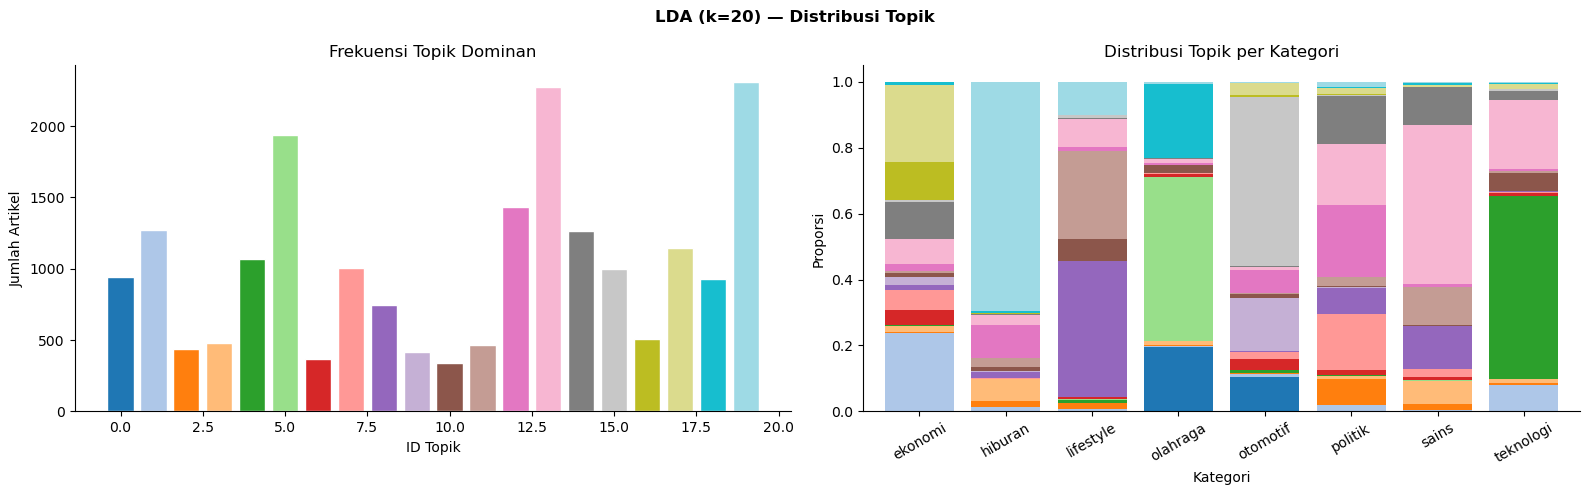

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'LDA (k={best_k_lda}) — Distribusi Topik', fontweight='bold')

tc_lda   = pd.Series(lda_dominant).value_counts().sort_index()
colors_l = sns.color_palette(PALETTE, best_k_lda)
axes[0].bar(tc_lda.index, tc_lda.values, color=colors_l, edgecolor='white')
axes[0].set_xlabel('ID Topik'); axes[0].set_ylabel('Jumlah Artikel')
axes[0].set_title('Frekuensi Topik Dominan')
axes[0].spines[['top','right']].set_visible(False)

df_lda_cat = pd.DataFrame({'kategori': df_meta['kategori'], 'topic': lda_dominant})
ct_lda_norm = pd.crosstab(df_lda_cat['kategori'], df_lda_cat['topic'], normalize='index')
ct_lda_norm.plot(kind='bar', stacked=True, ax=axes[1], colormap=PALETTE, width=0.8, legend=False)
axes[1].set_xlabel('Kategori'); axes[1].set_ylabel('Proporsi')
axes[1].set_title('Distribusi Topik per Kategori')
axes[1].tick_params(axis='x', rotation=30)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig02_lda_dist.png'), dpi=150, bbox_inches='tight')
plt.show()


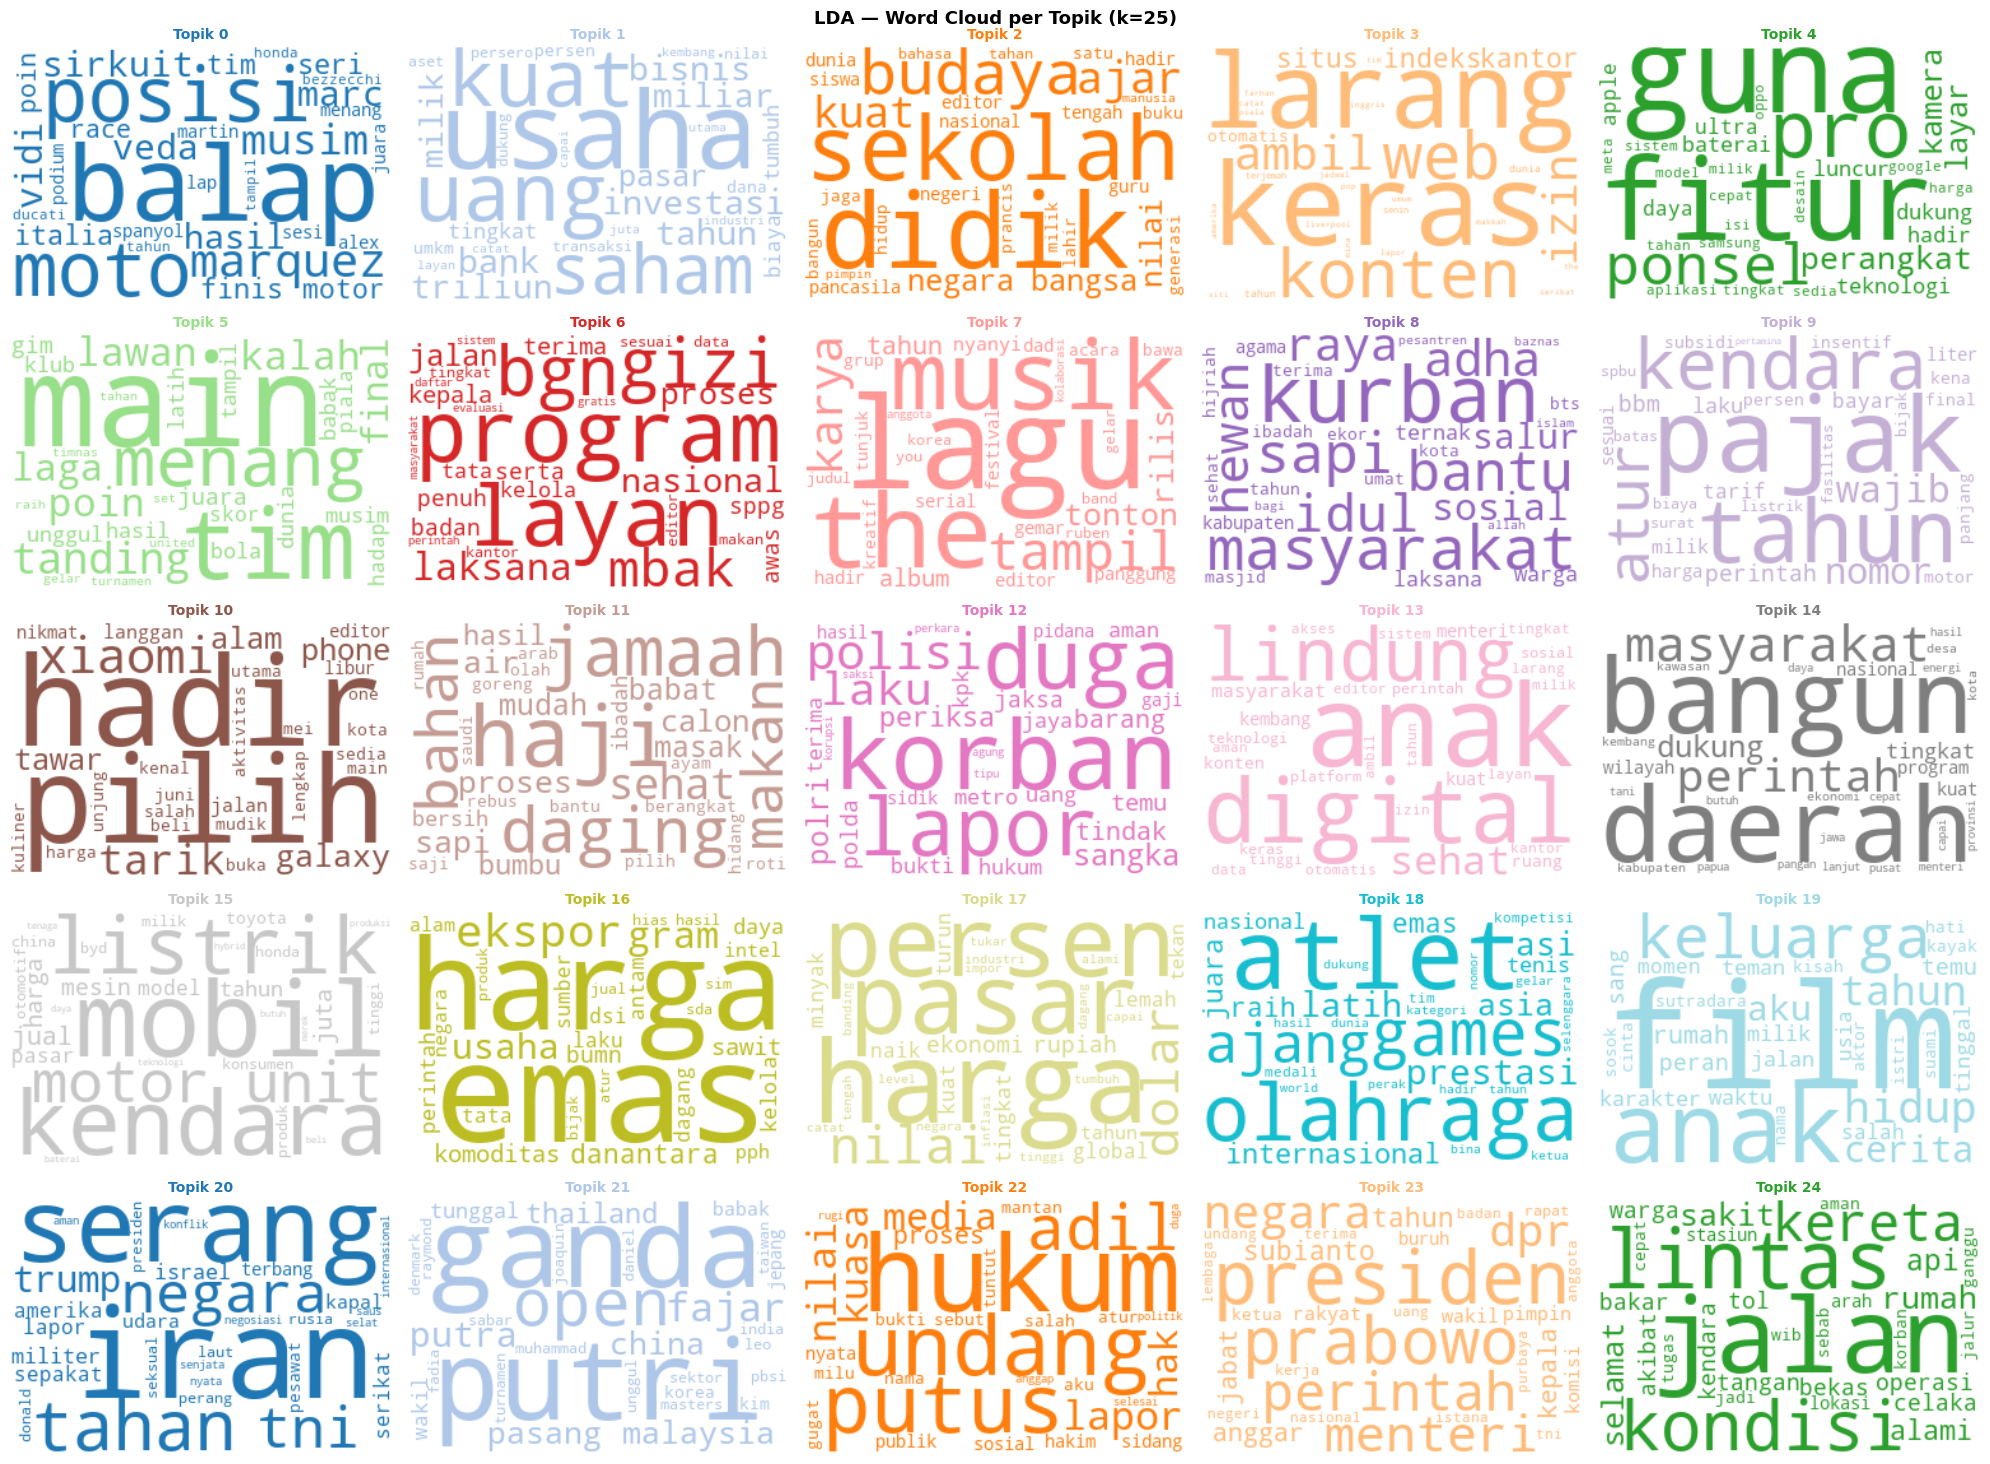

In [68]:
nrows = -(-best_k_lda // 5)
fig, axes = plt.subplots(nrows, 5, figsize=(20, nrows*3))
axes = axes.flatten()
colors_wc = sns.color_palette(PALETTE, best_k_lda)

for i in range(best_k_lda):
    words = best_lda.show_topic(i, topn=30)
    wf    = {w: p for w, p in words}
    rgb   = tuple(int(x*255) for x in colors_wc[i][:3])
    hc    = '#{:02x}{:02x}{:02x}'.format(*rgb)
    wc    = WordCloud(width=300, height=200, background_color='white',
                     color_func=lambda *a, **kw: hc, max_words=30)
    wc.generate_from_frequencies(wf)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'Topik {i}', fontsize=10, fontweight='bold', color=hc)

for j in range(best_k_lda, len(axes)): axes[j].set_visible(False)
fig.suptitle(f'LDA — Word Cloud per Topik (k={best_k_lda})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig03_lda_wordcloud.png'), dpi=130, bbox_inches='tight')
plt.show()


In [69]:
pyLDAvis.enable_notebook()
vis_lda = pyLDAvis.gensim_models.prepare(best_lda, corpus_bow, id2word, sort_topics=False)
pyLDAvis.save_html(vis_lda, os.path.join(OUTPUT_DIR, 'pyldavis_output.html'))
print('pyldavis_output.html')
vis_lda


/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=97018) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=97018) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=97018) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=97018) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarnin

pyldavis_output.html


PreparedData(topic_coordinates=              x         y  topics  cluster      Freq
topic                                               
0     -0.240053  0.039676       1        1  3.213267
1      0.135965  0.134844       2        1  4.604565
2      0.039898 -0.095964       3        1  4.516379
3     -0.101515 -0.056696       4        1  4.039983
4     -0.000260  0.205622       5        1  4.492500
5     -0.221724  0.034013       6        1  5.459150
6      0.162148 -0.044230       7        1  4.125611
7     -0.132791 -0.005740       8        1  2.804184
8      0.065756 -0.148210       9        1  3.015748
9      0.122048  0.044557      10        1  2.096229
10    -0.064611  0.130549      11        1  3.394663
11    -0.009706  0.029524      12        1  2.104436
12     0.051263 -0.165950      13        1  3.323718
13     0.135604 -0.001387      14        1  7.088686
14     0.166124  0.020530      15        1  7.593388
15    -0.001624  0.249986      16        1  4.278827
16     0.148904  0.084908      17        1  2.404724
17     0.102995  0.130540      18        1  5.297526
18    -0.124980 -0.006508      19        1  3.840722
19    -0.118794 -0.061339      20        1  6.040355
20     0.012639 -0.120689      21        1  2.461136
21    -0.277320 -0.045437      22        1  1.980463
22     0.034274 -0.162321      23        1  3.594531
23     0.128825 -0.142348      24        1  4.006443
24    -0.013064 -0.047928      25        1  4.222764, topic_info=          Term          Freq         Total Category  logprob  loglift
114   presiden  10279.000000  10279.000000  Default  30.0000  30.0000
5826    konten  11024.000000  11024.000000  Default  29.0000  29.0000
4301    larang  10435.000000  10435.000000  Default  28.0000  28.0000
3296       web   9867.000000   9867.000000  Default  27.0000  27.0000
463      harga  15026.000000  15026.000000  Default  26.0000  26.0000
...        ...           ...           ...      ...      ...      ...
765      tugas    955.336046   3836.628963  Topic25  -5.1505   1.7744
790       jadi    886.137209   3018.567689  Topic25  -5.2256   1.9390
746     korban    960.800991   4718.741533  Topic25  -5.1447   1.5732
229       aman    975.919050   5908.434253  Topic25  -5.1291   1.3639
22       cepat    954.046457   7238.017354  Topic25  -5.1518   1.1383

[1734 rows x 6 columns], token_table=       Topic      Freq      Term
term                            
5516      25  0.994297     aaron
3250       3  0.904959      abdi
3250       7  0.032569      abdi
3250       9  0.060486      abdi
2022       2  0.014355     acara
...      ...       ...       ...
8246      14  0.973030       zon
11544     10  0.997258      zoni
5030       5  0.996528      zoom
8247      15  0.990533    zulhas
7899       9  0.995192  zulhijah

[6229 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25])

## 2. NMF — Non-Negative Matrix Factorization

In [70]:
corpus_joined = [' '.join(doc) for doc in corpus_tokenized]

tfidf_vectorizer = TfidfVectorizer(
    max_df       = 0.85,
    min_df       = 3,          
    max_features = 15000,
    ngram_range  = (1, 1)
)
tfidf_matrix = tfidf_vectorizer.fit_transform(corpus_joined)
tfidf_vocab  = tfidf_vectorizer.get_feature_names_out()

print(f'Shape TF-IDF matrix : {tfidf_matrix.shape}')
print(f'Vocabulary size     : {len(tfidf_vocab):,}')


Shape TF-IDF matrix : (20334, 15000)
Vocabulary size     : 15,000


In [71]:
def compute_coherence_nmf(nmf_model, vocab, tokenized_corpus, dictionary, n_top=10):
    topics_words = []
    for comp in nmf_model.components_:
        top_words = [vocab[i] for i in comp.argsort()[:-n_top-1:-1]]
        topics_words.append(top_words)
    cm = CoherenceModel(topics=topics_words, texts=tokenized_corpus,
                        dictionary=dictionary, coherence='c_v')
    return cm.get_coherence(), topics_words  # <-- pastikan ini yang ada


In [72]:
nmf_models       = {}
nmf_coherence    = {}
nmf_topics_words = {}

for k in K_VALUES:
    print(f'Training NMF k={k} ...', end=' ', flush=True)
    nmf = NMF(
        n_components = k,
        random_state = RANDOM_SEED,
        max_iter     = 400,
        init         = 'nndsvda'
    )
    nmf.fit(tfidf_matrix)
    nmf_models[k] = nmf

    coh, tw = compute_coherence_nmf(nmf, tfidf_vocab, corpus_tokenized, id2word)
    nmf_coherence[k]    = coh
    nmf_topics_words[k] = tw
    print(f'C_v={coh:.4f}')

best_k_nmf = max(nmf_coherence, key=nmf_coherence.get)
print(f'\n k NMF = {best_k_nmf} (C_v = {nmf_coherence[best_k_nmf]:.4f})')


Training NMF k=5 ... C_v=0.7756
Training NMF k=10 ... C_v=0.8104
Training NMF k=15 ... C_v=0.8097
Training NMF k=20 ... C_v=0.8165
Training NMF k=25 ... C_v=0.8250
Training NMF k=30 ... C_v=0.8155

 k NMF = 25 (C_v = 0.8250)


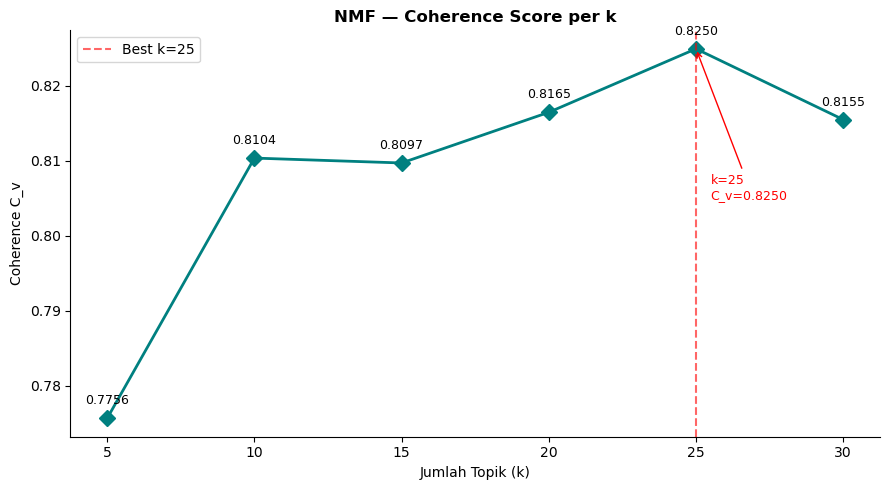

In [73]:
fig, ax = plt.subplots(figsize=(9, 5))
ks_n  = list(nmf_coherence.keys())
cvs_n = list(nmf_coherence.values())

ax.plot(ks_n, cvs_n, marker='D', color='teal', lw=2, ms=8)
ax.axvline(best_k_nmf, color='red', ls='--', alpha=0.6, label=f'Best k={best_k_nmf}')
ax.annotate(f'k={best_k_nmf}\nC_v={nmf_coherence[best_k_nmf]:.4f}',
            xy=(best_k_nmf, nmf_coherence[best_k_nmf]),
            xytext=(best_k_nmf+0.5, nmf_coherence[best_k_nmf]-0.02),
            fontsize=9, color='red', arrowprops=dict(arrowstyle='->', color='red'))
for k_v, cv_v in zip(ks_n, cvs_n):
    ax.annotate(f'{cv_v:.4f}', (k_v, cv_v), textcoords='offset points',
                xytext=(0, 10), ha='center', fontsize=9)
ax.set_xlabel('Jumlah Topik (k)'); ax.set_ylabel('Coherence C_v')
ax.set_title('NMF — Coherence Score per k', fontweight='bold')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig04_nmf_coherence.png'), dpi=150, bbox_inches='tight')
plt.show()


In [74]:
best_nmf       = nmf_models[best_k_nmf]
nmf_topic_words = {}

print(f'TOP WORDS PER TOPIK — NMF k={best_k_nmf}\n')
for tid, comp in enumerate(best_nmf.components_):
    top_idx   = comp.argsort()[:-11:-1]
    top_words = [tfidf_vocab[i] for i in top_idx]
    nmf_topic_words[tid] = top_words
    probs = [f'{tfidf_vocab[i]}({comp[i]:.3f})' for i in top_idx]
    print(f'Topik {tid:2d}: {"  ".join(probs)}')

W_nmf        = best_nmf.transform(tfidf_matrix)
nmf_dominant = np.argmax(W_nmf, axis=1)
print(f'\nShape W matrix NMF : {W_nmf.shape}')


TOP WORDS PER TOPIK — NMF k=25

Topik  0: industri(2.085)  ekonomi(1.819)  usaha(1.569)  tumbuh(1.536)  kuat(1.144)  kembang(1.113)  nasional(1.088)  tingkat(1.065)  investasi(0.965)  sektor(0.962)
Topik  1: balap(1.846)  marquez(1.705)  moto(1.668)  marc(0.900)  alex(0.610)  bezzecchi(0.592)  ducati(0.583)  race(0.521)  acosta(0.502)  martin(0.491)
Topik  2: open(1.000)  gim(0.824)  ganda(0.687)  babak(0.636)  fajar(0.628)  alwi(0.623)  masters(0.561)  fikri(0.554)  putra(0.529)  main(0.495)
Topik  3: rupiah(2.738)  dolar(2.483)  lemah(1.447)  tukar(1.357)  uang(1.204)  purbaya(1.165)  nilai(1.005)  pasar(0.890)  bank(0.698)  level(0.658)
Topik  4: mobil(2.556)  listrik(2.356)  unit(1.125)  motor(1.078)  byd(1.039)  kendara(1.035)  jual(0.825)  honda(0.517)  juta(0.505)  hybrid(0.473)
Topik  5: prabowo(2.656)  presiden(2.271)  negara(1.022)  subianto(0.615)  prancis(0.612)  kunjung(0.527)  pancasila(0.471)  bangsa(0.449)  dpr(0.430)  ekonomi(0.404)
Topik  6: kurban(2.537)  sapi(1.512)

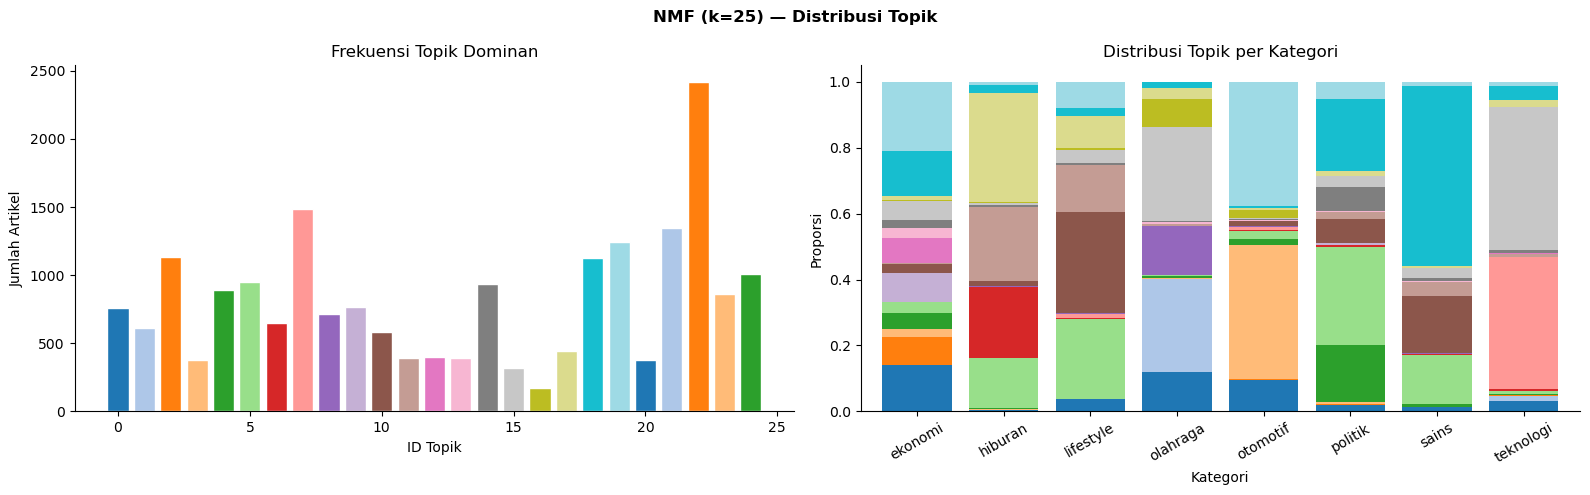

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'NMF (k={best_k_nmf}) — Distribusi Topik', fontweight='bold')

tc_nmf   = pd.Series(nmf_dominant).value_counts().sort_index()
colors_n = sns.color_palette(PALETTE, best_k_nmf)
axes[0].bar(tc_nmf.index, tc_nmf.values, color=colors_n, edgecolor='white')
axes[0].set_xlabel('ID Topik'); axes[0].set_ylabel('Jumlah Artikel')
axes[0].set_title('Frekuensi Topik Dominan')
axes[0].spines[['top','right']].set_visible(False)

df_nmf_cat = pd.DataFrame({'kategori': df_meta['kategori'], 'topic': nmf_dominant})
ct_nmf_norm = pd.crosstab(df_nmf_cat['kategori'], df_nmf_cat['topic'], normalize='index')
ct_nmf_norm.plot(kind='bar', stacked=True, ax=axes[1], colormap=PALETTE, width=0.8, legend=False)
axes[1].set_xlabel('Kategori'); axes[1].set_ylabel('Proporsi')
axes[1].set_title('Distribusi Topik per Kategori')
axes[1].tick_params(axis='x', rotation=30)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig05_nmf_dist.png'), dpi=150, bbox_inches='tight')
plt.show()


## 3. BERTopic


In [78]:
EMBEDDING_MODEL = 'paraphrase-multilingual-MiniLM-L12-v2'
EMBEDDINGS_PATH = os.path.join(OUTPUT_DIR, 'embeddings_bert.npy')

if os.path.exists(EMBEDDINGS_PATH):
    print(f'Cache ditemukan — loading embeddings...')
    embeddings = np.load(EMBEDDINGS_PATH)
    print(f'Shape: {embeddings.shape}')
else:
    print(f'Generating embeddings dengan {EMBEDDING_MODEL}...')
    sentence_model = SentenceTransformer(EMBEDDING_MODEL)
    embeddings = sentence_model.encode(
        corpus_bert,
        show_progress_bar = True,
        batch_size        = 64
    )
    np.save(EMBEDDINGS_PATH, embeddings)
    print(f'Shape: {embeddings.shape} — disimpan ke cache')


Cache ditemukan — loading embeddings...
Shape: (20334, 384)


In [79]:
umap_model = UMAP(
    n_neighbors  = 15,
    n_components = 5,
    min_dist     = 0.0,
    metric       = 'cosine',
    random_state = RANDOM_SEED,
    low_memory   = True
)

hdbscan_model = HDBSCAN(
    min_cluster_size         = 50,
    metric                   = 'euclidean',
    cluster_selection_method = 'eom',
    prediction_data          = True
)

try:
    sentence_model
except NameError:
    sentence_model = SentenceTransformer(EMBEDDING_MODEL)


In [80]:
topic_model = BERTopic(
    embedding_model = sentence_model,
    umap_model      = umap_model,
    hdbscan_model   = hdbscan_model,
    nr_topics       = 'auto',
    top_n_words     = 15,
    verbose         = True,
    language        = 'multilingual',
    calculate_probabilities = True
)

topics_auto, probs_auto = topic_model.fit_transform(corpus_bert, embeddings)
n_topics_auto = topic_model.get_topic_info().shape[0] - 1  # -1 untuk noise

print(f'\nTopik ditemukan (auto)  : {n_topics_auto}')
print(f'   Noise docs (-1)         : {sum(t == -1 for t in topics_auto)} ({sum(t==-1 for t in topics_auto)/len(topics_auto)*100:.1f}%)')
print('\n', topic_model.get_topic_info()[['Topic','Count','Name']].head(15).to_string(index=False))


2026-06-08 00:48:58,490 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-08 00:49:09,378 - BERTopic - Dimensionality - Completed ✓
2026-06-08 00:49:09,379 - BERTopic - Cluster - Start clustering the reduced embeddings
/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=97018) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=97018) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=97018) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/opt/anaconda3/lib/python3.12/site-packages/joblib/externals/loky/backend/for


Topik ditemukan (auto)  : 19
   Noise docs (-1)         : 5528 (27.2%)

  Topic  Count                                Name
    -1   5528  -1_jakarta_tahun_masyarakat_negara
     0   6909   0_jakarta_anak_pemerintah_digital
     1   3991       1_tim_poin_atlet_pertandingan
     2    915     2_mobil_kendaraan_listrik_motor
     3    663           3_ponsel_pro_kamera_apple
     4    555 4_jalan_kereta_kendaraan_kecelakaan
     5    431            5_kurban_sapi_hewan_ekor
     6    262         6_saham_ihsg_indeks_melemah
     7    162        7_iran_israel_trump_serangan
     8    134         8_pengguna_fitur_google_app
     9    128       9_china_robot_teknologi_space
    10     96            10_emas_gram_harga_antam
    11     84  11_israel_wni_kemanusiaan_flotilla
    12     81       12_kesehatan_layanan_bpjs_jkn
    13     80    13_tni_pertahanan_pesawat_rafale


In [81]:
K_BERT_TARGET = best_k_lda

if n_topics_auto > K_BERT_TARGET:
    print(f'Mereduksi {n_topics_auto} → {K_BERT_TARGET} topik...')
    topic_model.reduce_topics(corpus_bert, nr_topics=K_BERT_TARGET)
    print('Reduksi selesai')
else:
    print(f'Topik ({n_topics_auto}) sudah ≤ target ({K_BERT_TARGET}), tidak direduksi')

topics_final  = topic_model.topics_
n_topics_final = topic_model.get_topic_info().shape[0] - 1
print(f'Jumlah topik final        : {n_topics_final}')
print(f'Noise docs (-1)           : {sum(t == -1 for t in topics_final)} ({sum(t==-1 for t in topics_final)/len(topics_final)*100:.1f}%)')


Topik (19) sudah ≤ target (25), tidak direduksi
Jumlah topik final        : 19
Noise docs (-1)           : 5528 (27.2%)


In [82]:
print(f'TOP WORDS PER TOPIK — BERTopic (k~{K_BERT_TARGET})\n')
print(topic_model.get_topic_info()[['Topic','Count','Name']].to_string(index=False))

bertopic_topic_words = {}
print('\n--- Detail top words ---')
for tid in sorted(set(topics_final)):
    if tid == -1: continue
    words = topic_model.get_topic(tid)
    if words:
        bertopic_topic_words[tid] = [w for w, _ in words[:10]]
        print(f'Topik {tid:2d}: {"  ".join([f"{w}({s:.3f})" for w,s in words[:8]])}')

# Coherence BERTopic
bert_words_list = [bertopic_topic_words[t] for t in sorted(bertopic_topic_words.keys())]
cm_bert = CoherenceModel(topics=bert_words_list, texts=corpus_tokenized,
                         dictionary=id2word, coherence='c_v')
bert_coherence_score = cm_bert.get_coherence()
print(f'\n BERTopic Coherence C_v : {bert_coherence_score:.4f}')


TOP WORDS PER TOPIK — BERTopic (k~25)

 Topic  Count                                      Name
    -1   5528        -1_jakarta_tahun_masyarakat_negara
     0   6909         0_jakarta_anak_pemerintah_digital
     1   3991             1_tim_poin_atlet_pertandingan
     2    915           2_mobil_kendaraan_listrik_motor
     3    663                 3_ponsel_pro_kamera_apple
     4    555       4_jalan_kereta_kendaraan_kecelakaan
     5    431                  5_kurban_sapi_hewan_ekor
     6    262               6_saham_ihsg_indeks_melemah
     7    162              7_iran_israel_trump_serangan
     8    134               8_pengguna_fitur_google_app
     9    128             9_china_robot_teknologi_space
    10     96                  10_emas_gram_harga_antam
    11     84        11_israel_wni_kemanusiaan_flotilla
    12     81             12_kesehatan_layanan_bpjs_jkn
    13     80          13_tni_pertahanan_pesawat_rafale
    14     71              14_redeem_kode_mobile_hadiah
    15   

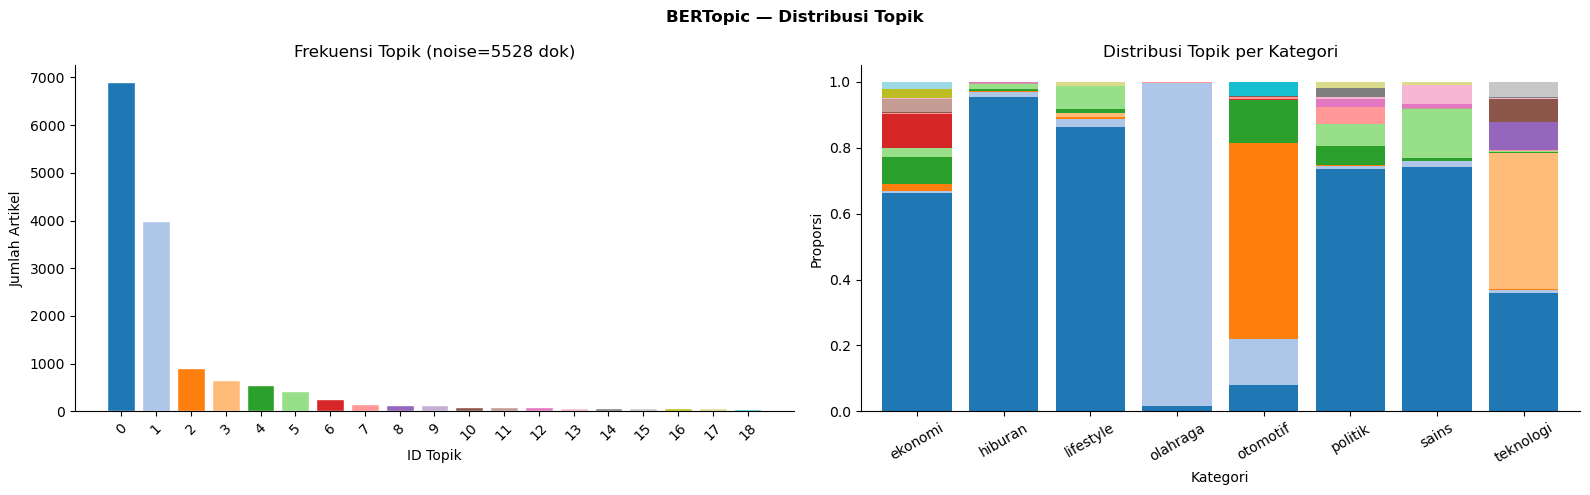

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('BERTopic — Distribusi Topik', fontweight='bold')

tc_bert = pd.Series(topics_final)
tc_bert_valid = tc_bert[tc_bert != -1].value_counts().sort_index()
axes[0].bar(tc_bert_valid.index.astype(str), tc_bert_valid.values,
            color=sns.color_palette(PALETTE, len(tc_bert_valid)), edgecolor='white')
axes[0].set_xlabel('ID Topik'); axes[0].set_ylabel('Jumlah Artikel')
axes[0].set_title(f'Frekuensi Topik (noise={sum(t==-1 for t in topics_final)} dok)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].spines[['top','right']].set_visible(False)

df_bert_cat = pd.DataFrame({'kategori': df_meta['kategori'], 'topic': topics_final})
df_bert_valid = df_bert_cat[df_bert_cat['topic'] != -1]
ct_bert_norm = pd.crosstab(df_bert_valid['kategori'], df_bert_valid['topic'], normalize='index')
ct_bert_norm.plot(kind='bar', stacked=True, ax=axes[1], colormap=PALETTE, width=0.8, legend=False)
axes[1].set_xlabel('Kategori'); axes[1].set_ylabel('Proporsi')
axes[1].set_title('Distribusi Topik per Kategori')
axes[1].tick_params(axis='x', rotation=30)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig06_bertopic_dist.png'), dpi=150, bbox_inches='tight')
plt.show()


Distribusi Noise per Kategori
           Total  Noise  Noise %
kategori                        
lifestyle    285    118     41.4
hiburan     3126   1261     40.3
ekonomi     4071   1561     38.3
politik     3886   1377     35.4
sains       1411    420     29.8
otomotif    1858    444     23.9
teknologi   1846    261     14.1
olahraga    3851     86      2.2


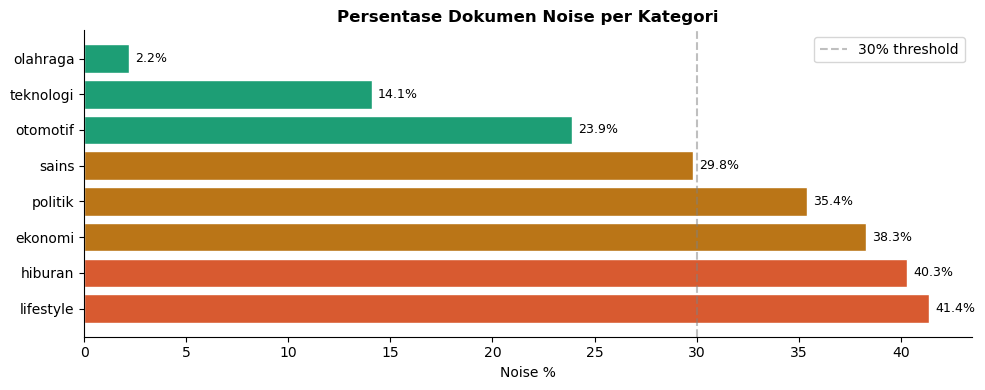

In [84]:
noise_mask = pd.Series(topics_final) == -1
noise_by_cat = df_meta[noise_mask.values]['kategori'].value_counts()
total_by_cat = df_meta['kategori'].value_counts()
noise_pct    = (noise_by_cat / total_by_cat * 100).round(1).sort_values(ascending=False)

noise_df = pd.DataFrame({
    'Total'     : total_by_cat,
    'Noise'     : noise_by_cat,
    'Noise %'   : noise_pct
}).dropna().sort_values('Noise %', ascending=False)

print('Distribusi Noise per Kategori')
print(noise_df.to_string())

fig, ax = plt.subplots(figsize=(10, 4))
colors_noise = ['#D85A30' if p > 40 else '#BA7517' if p > 25 else '#1D9E75'
                for p in noise_df['Noise %']]
bars = ax.barh(noise_df.index, noise_df['Noise %'], color=colors_noise, edgecolor='white')
for bar, val in zip(bars, noise_df['Noise %']):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f'{val}%', va='center', fontsize=9)
ax.set_xlabel('Noise %'); ax.set_title('Persentase Dokumen Noise per Kategori', fontweight='bold')
ax.axvline(30, color='gray', ls='--', alpha=0.5, label='30% threshold')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig07_noise_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()


In [85]:
if 'tanggal' in df_meta.columns:
    df_time = df_meta.copy()
    df_time['topic_bert'] = topics_final
    df_time['tanggal_dt'] = pd.to_datetime(df_time['tanggal'],
                                            format='mixed', dayfirst=False,
                                            errors='coerce')
    df_time['bulan'] = df_time['tanggal_dt'].dt.to_period('M').astype(str)

    df_valid_time = df_time[df_time['topic_bert'] != -1]
    top6 = df_valid_time['topic_bert'].value_counts().head(6).index.tolist()

    pivot = (df_valid_time[df_valid_time['topic_bert'].isin(top6)]
             .groupby(['bulan','topic_bert']).size().unstack(fill_value=0))

    fig, ax = plt.subplots(figsize=(14, 5))
    colors_t = sns.color_palette(PALETTE, len(top6))
    for i, tid in enumerate(top6):
        if tid in pivot.columns:
            ax.plot(pivot.index, pivot[tid], 'o-', color=colors_t[i],
                    lw=2, ms=5, label=f'T{tid}')
    ax.set_title('Topic Over Time — Top 6 Topik BERTopic per Bulan', fontweight='bold')
    ax.set_xlabel('Bulan'); ax.set_ylabel('Jumlah Artikel')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
    ax.spines[['top','right']].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'fig08_topic_over_time.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Kolom tanggal tidak ditemukan di metadata — topic over time dilewati.')


Kolom tanggal tidak ditemukan di metadata — topic over time dilewati.


## 4. Perbandingan Model Skenario S1

Membandingkan LDA, NMF, dan BERTopic berdasarkan **Coherence Score C_v** untuk semua nilai k.

In [86]:
rows = []
for k in K_VALUES:
    rows.append({
        'k'            : k,
        'LDA C_v'      : round(lda_coherence.get(k, float('nan')), 4),
        'LDA Perp'     : round(lda_perplexity.get(k, float('nan')), 2),
        'NMF C_v'      : round(nmf_coherence.get(k, float('nan')), 4),
        'BERTopic C_v' : round(bert_coherence_score, 4) if k == K_BERT_TARGET else '-'
    })

df_comparison = pd.DataFrame(rows)
print('=== TABEL PERBANDINGAN COHERENCE — SKENARIO S1 ===')
print(df_comparison.to_string(index=False))

print(f'\n=== RINGKASAN MODEL TERBAIK ===')
print(f'LDA      best k={best_k_lda:2d} | C_v = {lda_coherence[best_k_lda]:.4f}')
print(f'NMF      best k={best_k_nmf:2d} | C_v = {nmf_coherence[best_k_nmf]:.4f}')
print(f'BERTopic k~{K_BERT_TARGET:2d}      | C_v = {bert_coherence_score:.4f}')
best_overall = max({'LDA': lda_coherence[best_k_lda],
                    'NMF': nmf_coherence[best_k_nmf],
                    'BERTopic': bert_coherence_score},
                   key=lambda x: {'LDA':lda_coherence[best_k_lda],
                                  'NMF':nmf_coherence[best_k_nmf],
                                  'BERTopic':bert_coherence_score}[x])
print(f'\nModel terbaik S1        : {best_overall}')


=== TABEL PERBANDINGAN COHERENCE — SKENARIO S1 ===
 k  LDA C_v  LDA Perp  NMF C_v BERTopic C_v
 5   0.5201     -7.79   0.7756            -
10   0.5787     -7.93   0.8104            -
15   0.5862     -8.45   0.8097            -
20   0.6076     -8.81   0.8165            -
25   0.6162     -9.06   0.8250        0.778
30   0.5854     -9.34   0.8155            -

=== RINGKASAN MODEL TERBAIK ===
LDA      best k=25 | C_v = 0.6162
NMF      best k=25 | C_v = 0.8250
BERTopic k~25      | C_v = 0.7780

Model terbaik S1        : NMF


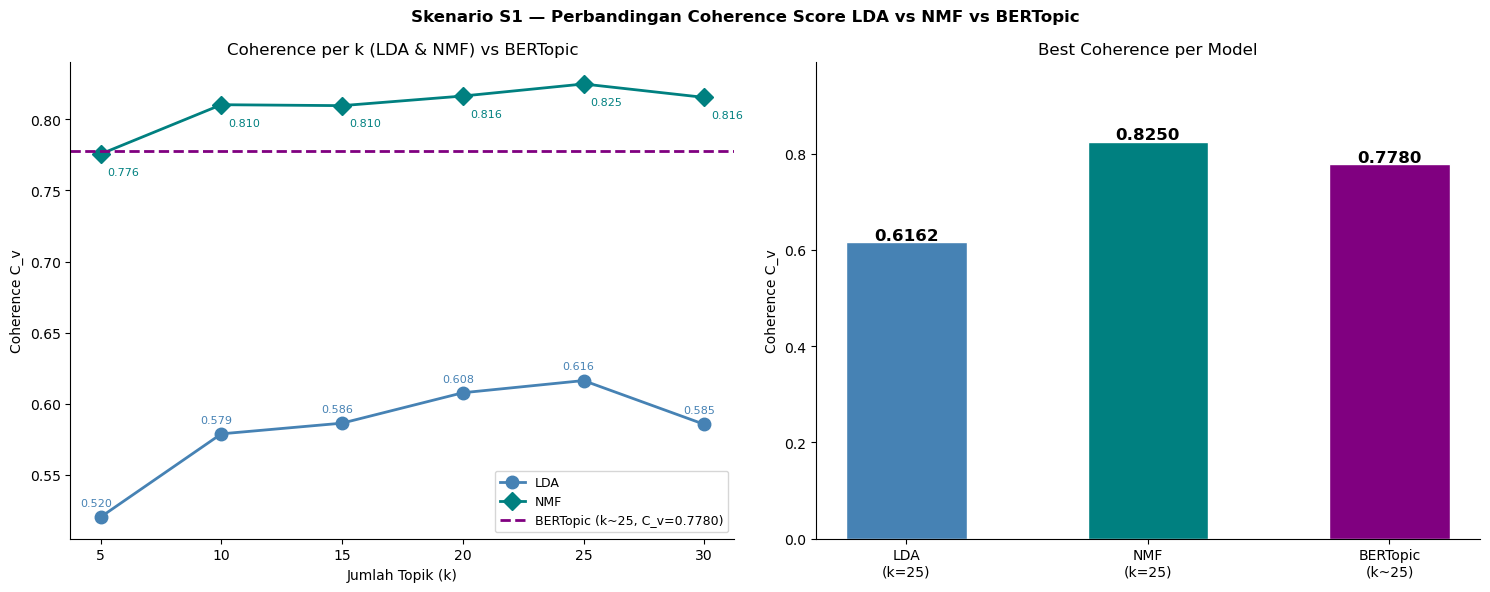

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Skenario S1 — Perbandingan Coherence Score LDA vs NMF vs BERTopic', fontweight='bold')

# Plot garis per k
axes[0].plot(K_VALUES, [lda_coherence[k] for k in K_VALUES],
             marker='o', color='steelblue', lw=2, ms=9, label='LDA')
axes[0].plot(K_VALUES, [nmf_coherence[k] for k in K_VALUES],
             marker='D', color='teal', lw=2, ms=9, label='NMF')
axes[0].axhline(bert_coherence_score, color='purple', lw=2, ls='--',
                label=f'BERTopic (k~{K_BERT_TARGET}, C_v={bert_coherence_score:.4f})')
# Annotasi nilai
for k in K_VALUES:
    axes[0].annotate(f'{lda_coherence[k]:.3f}', (k, lda_coherence[k]),
                     textcoords='offset points', xytext=(-15, 8), fontsize=8, color='steelblue')
    axes[0].annotate(f'{nmf_coherence[k]:.3f}', (k, nmf_coherence[k]),
                     textcoords='offset points', xytext=(5, -15), fontsize=8, color='teal')
axes[0].set_xlabel('Jumlah Topik (k)'); axes[0].set_ylabel('Coherence C_v')
axes[0].set_title('Coherence per k (LDA & NMF) vs BERTopic')
axes[0].legend(fontsize=9)
axes[0].spines[['top','right']].set_visible(False)

# Bar chart best model
best_vals   = [lda_coherence[best_k_lda], nmf_coherence[best_k_nmf], bert_coherence_score]
best_models = [f'LDA\n(k={best_k_lda})', f'NMF\n(k={best_k_nmf})', f'BERTopic\n(k~{K_BERT_TARGET})']
colors_bar  = ['steelblue', 'teal', 'purple']
bars = axes[1].bar(best_models, best_vals, color=colors_bar, width=0.5, edgecolor='white')
for bar, val in zip(bars, best_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Coherence C_v')
axes[1].set_title('Best Coherence per Model')
axes[1].set_ylim(0, max(best_vals)*1.2)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig09_s1_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()


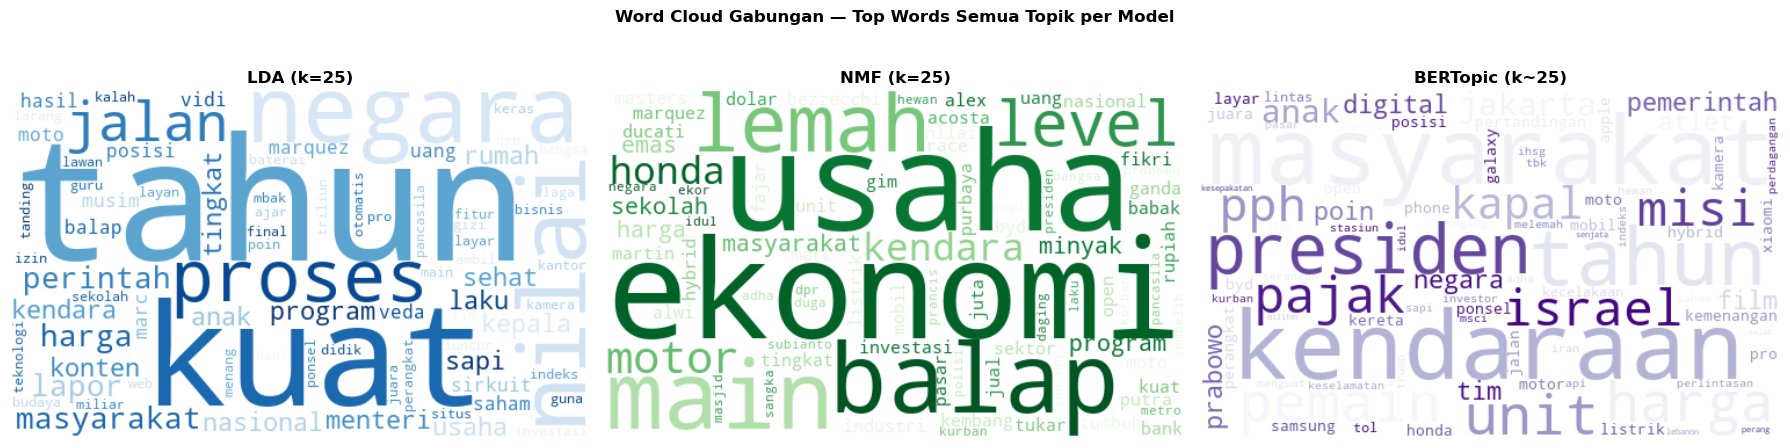

In [88]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Word Cloud Gabungan — Top Words Semua Topik per Model', fontweight='bold')

def make_wc(words, title, ax, cmap='viridis'):
    wc = WordCloud(width=500, height=300, background_color='white',
                   max_words=80, colormap=cmap, collocations=False)
    wc.generate(' '.join(words * 3))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off'); ax.set_title(title, fontweight='bold', fontsize=12)

all_lda  = [w for ws in lda_topic_words.values() for w in ws]
all_nmf  = [w for ws in nmf_topic_words.values() for w in ws]
all_bert = [w for ws in bertopic_topic_words.values() for w in ws]

make_wc(all_lda,  f'LDA (k={best_k_lda})',        axes[0], cmap='Blues')
make_wc(all_nmf,  f'NMF (k={best_k_nmf})',        axes[1], cmap='Greens')
make_wc(all_bert, f'BERTopic (k~{K_BERT_TARGET})', axes[2], cmap='Purples')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig10_wordcloud_all.png'), dpi=150, bbox_inches='tight')
plt.show()


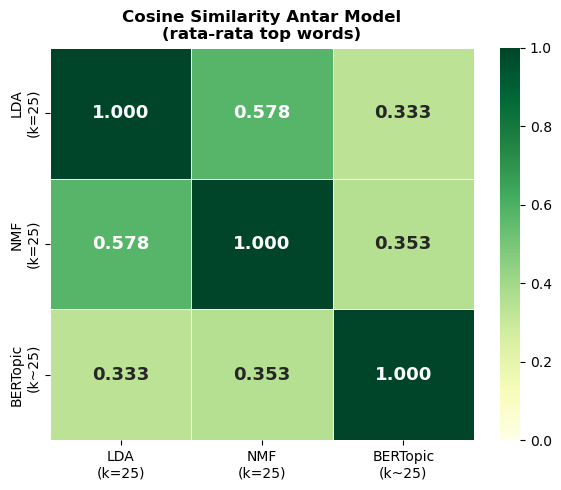

LDA–NMF      : 0.578
LDA–BERTopic : 0.333
NMF–BERTopic : 0.353


In [89]:
from sklearn.feature_extraction.text import CountVectorizer as CV2

def topics_to_str(tw_dict):
    return [' '.join(words) for words in tw_dict.values()]

lda_docs  = topics_to_str(lda_topic_words)
nmf_docs  = topics_to_str(nmf_topic_words)
bert_docs = topics_to_str(bertopic_topic_words)

cv2 = CV2()
cv2.fit(lda_docs + nmf_docs + bert_docs)

lda_mean  = cv2.transform(lda_docs).toarray().mean(axis=0, keepdims=True)
nmf_mean  = cv2.transform(nmf_docs).toarray().mean(axis=0, keepdims=True)
bert_mean = cv2.transform(bert_docs).toarray().mean(axis=0, keepdims=True)
mat       = np.vstack([lda_mean, nmf_mean, bert_mean])
sim       = cosine_similarity(mat)

fig, ax = plt.subplots(figsize=(6, 5))
model_names = [f'LDA\n(k={best_k_lda})', f'NMF\n(k={best_k_nmf})', f'BERTopic\n(k~{K_BERT_TARGET})']
sns.heatmap(sim, annot=True, fmt='.3f', cmap='YlGn',
            xticklabels=model_names, yticklabels=model_names,
            linewidths=0.5, linecolor='white', vmin=0, vmax=1, ax=ax,
            annot_kws={'size': 13, 'weight': 'bold'})
ax.set_title('Cosine Similarity Antar Model\n(rata-rata top words)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig11_similarity_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'LDA–NMF      : {sim[0,1]:.3f}')
print(f'LDA–BERTopic : {sim[0,2]:.3f}')
print(f'NMF–BERTopic : {sim[1,2]:.3f}')


In [90]:
df_labels = df_meta.copy()
df_labels['topic_lda']      = lda_dominant
df_labels['topic_nmf']      = nmf_dominant
df_labels['topic_bertopic'] = topics_final
df_labels['bertopic_outlier'] = (df_labels['topic_bertopic'] == -1).astype(int)

for t in range(best_k_lda):
    df_labels[f'lda_prob_t{t}'] = lda_doc_topics[:, t]

print(f'Shape df_labels : {df_labels.shape}')
print(f'Kolom           : {df_labels.columns.tolist()}')
df_labels.head(3)


Shape df_labels : (20334, 32)
Kolom           : ['portal', 'kategori', 'judul', 'topic_lda', 'topic_nmf', 'topic_bertopic', 'bertopic_outlier', 'lda_prob_t0', 'lda_prob_t1', 'lda_prob_t2', 'lda_prob_t3', 'lda_prob_t4', 'lda_prob_t5', 'lda_prob_t6', 'lda_prob_t7', 'lda_prob_t8', 'lda_prob_t9', 'lda_prob_t10', 'lda_prob_t11', 'lda_prob_t12', 'lda_prob_t13', 'lda_prob_t14', 'lda_prob_t15', 'lda_prob_t16', 'lda_prob_t17', 'lda_prob_t18', 'lda_prob_t19', 'lda_prob_t20', 'lda_prob_t21', 'lda_prob_t22', 'lda_prob_t23', 'lda_prob_t24']


,portal,kategori,judul,topic_lda,topic_nmf,topic_bertopic,bertopic_outlier,lda_prob_t0,lda_prob_t1,lda_prob_t2,...,lda_prob_t15,lda_prob_t16,lda_prob_t17,lda_prob_t18,lda_prob_t19,lda_prob_t20,lda_prob_t21,lda_prob_t22,lda_prob_t23,lda_prob_t24
0,detik,ekonomi,VKTR Kirim 30 Bus Listrik ke Transjakarta Sepa...,1,4,2,0,0.000114,0.377059,0.000326,...,0.351498,0.000133,0.092644,0.000193,0.000343,0.000174,0.000135,0.000274,0.007073,0.000295
1,detik,ekonomi,"Batal Berangkat Haji, Purbaya Pakai Duitnya bu...",23,6,5,0,0.000421,0.000936,0.001200,...,0.000747,0.000491,0.000968,0.000710,0.088776,0.000642,0.000495,0.001009,0.381401,0.001084
2,detik,ekonomi,"PT DSI Dibentuk, Pemerintah Pede Bisa Genjot D...",16,11,0,0,0.000167,0.107082,0.000475,...,0.000296,0.335690,0.250133,0.000281,0.000500,0.000254,0.000196,0.055084,0.053456,0.000429


=== MULTI-LABEL MATRIX (threshold=0.15) ===
Shape              : (20334, 25)
Rata-rata label/dok: 1.94
Min / Max label    : 0 / 5


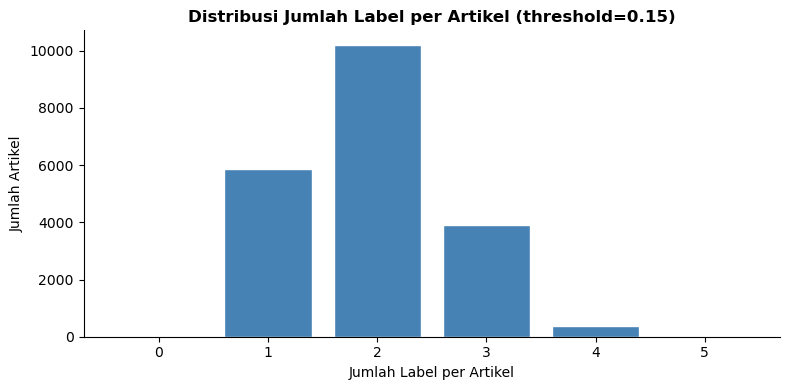

In [91]:
THRESHOLD = 0.15   # dokumen masuk ke topik t jika prob >= threshold

multilabel_matrix = (lda_doc_topics >= THRESHOLD).astype(int)
n_labels_per_doc  = multilabel_matrix.sum(axis=1)

print(f'=== MULTI-LABEL MATRIX (threshold={THRESHOLD}) ===')
print(f'Shape              : {multilabel_matrix.shape}')
print(f'Rata-rata label/dok: {n_labels_per_doc.mean():.2f}')
print(f'Min / Max label    : {n_labels_per_doc.min()} / {n_labels_per_doc.max()}')

dist = pd.Series(n_labels_per_doc).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dist.index, dist.values, color='steelblue', edgecolor='white')
ax.set_xlabel('Jumlah Label per Artikel'); ax.set_ylabel('Jumlah Artikel')
ax.set_title(f'Distribusi Jumlah Label per Artikel (threshold={THRESHOLD})', fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'fig12_multilabel_dist.png'), dpi=150, bbox_inches='tight')
plt.show()


In [92]:
df_labels.to_csv(os.path.join(OUTPUT_DIR, 'topic_labels.csv'), index=False)
df_labels.to_pickle(os.path.join(OUTPUT_DIR, 'topic_labels.pkl'))
np.save(os.path.join(OUTPUT_DIR, 'multilabel_matrix.npy'), multilabel_matrix)
df_comparison.to_csv(os.path.join(OUTPUT_DIR, 'topic_model_comparison_s1.csv'), index=False)

print(f'  {OUTPUT_DIR}/topic_labels.csv              → label topik per artikel')
print(f'  {OUTPUT_DIR}/topic_labels.pkl              → versi pickle')
print(f'  {OUTPUT_DIR}/multilabel_matrix.npy         → matrix multi-label LDA')
print(f'  {OUTPUT_DIR}/topic_model_comparison_s1.csv → tabel perbandingan coherence')
print(f'  {OUTPUT_DIR}/embeddings_bert.npy           → embedding BERTopic (cache)')


  /Users/lathifash/Documents/PERKULIAHAN_SEM8/TEXT MINING/FP/fp-textmining/output/topic_labels.csv              → label topik per artikel
  /Users/lathifash/Documents/PERKULIAHAN_SEM8/TEXT MINING/FP/fp-textmining/output/topic_labels.pkl              → versi pickle
  /Users/lathifash/Documents/PERKULIAHAN_SEM8/TEXT MINING/FP/fp-textmining/output/multilabel_matrix.npy         → matrix multi-label LDA
  /Users/lathifash/Documents/PERKULIAHAN_SEM8/TEXT MINING/FP/fp-textmining/output/topic_model_comparison_s1.csv → tabel perbandingan coherence
  /Users/lathifash/Documents/PERKULIAHAN_SEM8/TEXT MINING/FP/fp-textmining/output/embeddings_bert.npy           → embedding BERTopic (cache)


In [93]:
print(f'  Dataset   : {len(corpus_tokenized):,} artikel')
print(f'  Portal    : {df_meta["portal"].nunique()} portal')
print(f'  Kategori  : {df_meta["kategori"].nunique()} kategori')
print(f'  K values  : {K_VALUES}')
print()
print(f'  LDA      best k={best_k_lda:2d} | C_v = {lda_coherence[best_k_lda]:.4f}')
print(f'  NMF      best k={best_k_nmf:2d} | C_v = {nmf_coherence[best_k_nmf]:.4f}')
print(f'  BERTopic k~{K_BERT_TARGET:2d}      | C_v = {bert_coherence_score:.4f}')
print()
models_cv = {'LDA':lda_coherence[best_k_lda], 'NMF':nmf_coherence[best_k_nmf], 'BERTopic':bert_coherence_score}
winner = max(models_cv, key=models_cv.get)
print(f'  Model terbaik S1 : {winner} (C_v = {models_cv[winner]:.4f})')
print()
print(f'  Noise BERTopic : {sum(t==-1 for t in topics_final):,} dok ({sum(t==-1 for t in topics_final)/len(topics_final)*100:.1f}%)')
print(f'  Multi-label    : avg {n_labels_per_doc.mean():.2f} label/artikel (threshold={THRESHOLD})')


  Dataset   : 20,334 artikel
  Portal    : 6 portal
  Kategori  : 8 kategori
  K values  : [5, 10, 15, 20, 25, 30]

  LDA      best k=25 | C_v = 0.6162
  NMF      best k=25 | C_v = 0.8250
  BERTopic k~25      | C_v = 0.7780

  Model terbaik S1 : NMF (C_v = 0.8250)

  Noise BERTopic : 5,528 dok (27.2%)
  Multi-label    : avg 1.94 label/artikel (threshold=0.15)
